<a href="https://colab.research.google.com/github/Khushal-Sonar/Machine_Learning_Lab/blob/main/Practical_No1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Student Name : Khushal Kantilal Sonar
*   Div :- A
*   Practical Batch : A-1
*   Roll No. 09
*   Date : 09/09/2026
*   Practical No. 01
*   Practical Name: Implement simple and multiple linear regression using Numpy and using Scikit-learn. Plot regression lines and residuals. Compute RMSE and R2 values.

1] Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2] Data Collection

In [ ]:
data = {
    "Study_Hours" : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Attendance" : [60, 85, 70, 95, 65, 80, 90, 75, 88, 72],
    "Marks": [32, 42, 47, 58, 61, 67, 76, 79, 88, 91]
}
df = pd.DataFrame(data)
print(df)

   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


3] EDA and Preprocessing

In [ ]:
print('First Five Rows:')
df.head(3)

First Five Rows:


,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47


In [ ]:
df.tail()

,Study_Hours,Attendance,Marks
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


In [ ]:
print('Shape of Dataset: ')
df.shape

Shape of Dataset: 


(10, 3)

In [ ]:
print('Information: ')
df.info()

Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [ ]:
print('Statistical Analysis:\n', df.describe())

Statistical Analysis:
        Study_Hours  Attendance      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.489125  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000  91.000000


In [ ]:
print('Check for null values: ')
df.isnull().sum()

Check for null values: 


,0
Study_Hours,0
Attendance,0
Marks,0


In [ ]:
df=df.dropna()
df

,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


In [ ]:
#duplicate values
df.duplicated().sum()


np.int64(0)

In [ ]:
df=df.drop_duplicates()
df

,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


Data Visualization

In [ ]:
df_corr=df.corr()
df_corr

,Study_Hours,Attendance,Marks
Study_Hours,1.000000,0.245955,0.994877
Attendance,0.245955,1.000000,0.331320
Marks,0.994877,0.331320,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

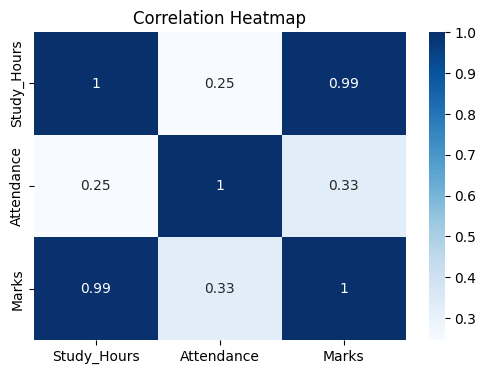

In [ ]:
#Correlation Heatmap
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(df_corr, annot=True, cmap="Blues")
plt.title('Correlation Heatmap')

A] Simple Linear Regression by Using Sckit-Learn

In [ ]:
#Feature Selection
x = df[['Study_Hours']]
y = df['Marks']

In [ ]:
x

,Study_Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


4] Model Building

In [ ]:
# Split dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
x_test

,Study_Hours
8,9
1,2
5,6


In [ ]:
# import Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
# Train the model
model.fit(x_train, y_train)


LinearRegression()

In [ ]:
# Predict the values
y_pred = model.predict(x_test)
y_pred

array([86.55445545, 41.22772277, 67.12871287])

In [ ]:
# Print Equation
print('Intercept : ', model.intercept_)
print('Slope:', model.coef_[0])

Intercept :  28.277227722772274
Slope: 6.475247524752477


SLR Equation

*   Marks = (6.48 * Study_Hours) + 28.27

5] Model Evaluation

In [ ]:
# Evaluation
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('RMSE:', round(rmse, 3))
print('R2 Score:', round(r2, 2))


RMSE: 0.949
R2 Score: 1.0


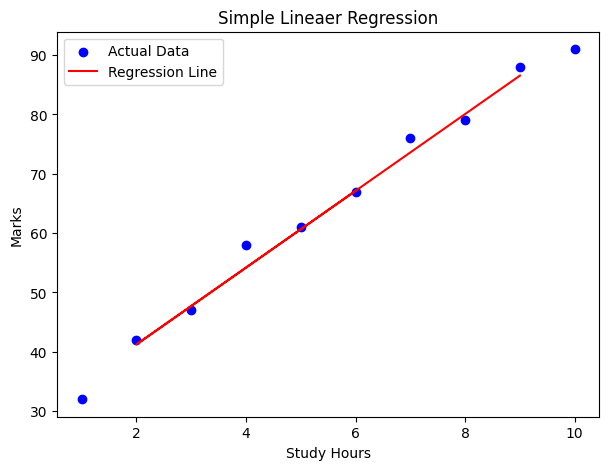

In [ ]:
# Regression Line
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, y_pred, color='red', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Lineaer Regression')
plt.legend()
plt.show()

Residual Plot

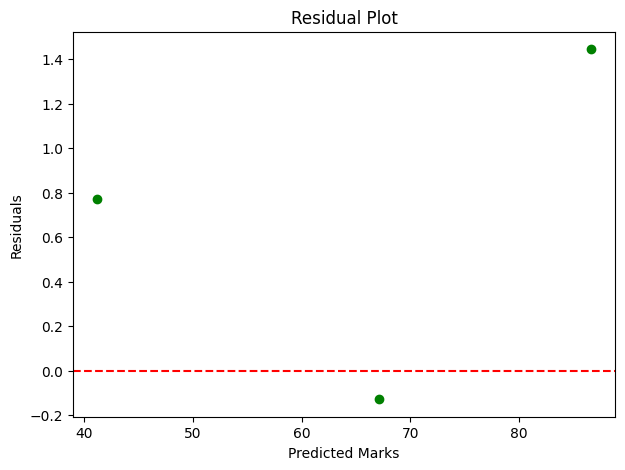

In [ ]:
from matplotlib.lines import lineStyles
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle="--")
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

B] Simple Linear Regression by using Numpy

In [ ]:
x = df["Study_Hours"].values
y = df["Marks"].values

In [ ]:
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [ ]:
x_mean = np.mean(x)
y_mean = np.mean(y)


In [ ]:
x_mean

np.float64(5.5)

In [ ]:
# Calculate slope
m = np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
# Calculate intercept
b = y_mean - m*x_mean
print("Slope = ", m)
print("Intercept = ", b)

Slope =  6.503030303030303
Intercept =  28.33333333333333


In [ ]:
#Prediction
y_pred_numpy = m*x + b
y_pred_numpy


array([34.83636364, 41.33939394, 47.84242424, 54.34545455, 60.84848485,
       67.35151515, 73.85454545, 80.35757576, 86.86060606, 93.36363636])

C] Multiple Linear Regression

In [ ]:
x = df[['Study_Hours', 'Attendance']]
y=df['Marks']
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
x_train

,Study_Hours,Attendance
0,1,60
7,8,75
2,3,70
9,10,72
4,5,65
3,4,95
6,7,90


Model Building

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

In [ ]:
# Prediction
y_pred = model.predict(x_test)
y_pred

array([88.08653885, 43.59718321, 67.84336712])

In [ ]:
import pandas as pd
# Model Parameters
print('Intercept: ', model.intercept_)
print("Coefficients",)
coeff=pd.DataFrame({
    'Feature':x.columns, 'Coefficient':model.coef_ })
print(coeff)

Intercept:  16.14458419831481
Coefficients
       Feature  Coefficient
0  Study_Hours     6.280539
1   Attendance     0.175194


Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error
print('Metrics Values of MLR:')
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae= mean_absolute_error(y_test, y_pred)
print('MAE:', mae)
print('RMSE: ', round(rmse, 2))
print('R2 Score: ', round(r2, 2))


Metrics Values of MLR:
MAE: 0.8423630615595409
RMSE:  1.04
R2 Score:  1.0


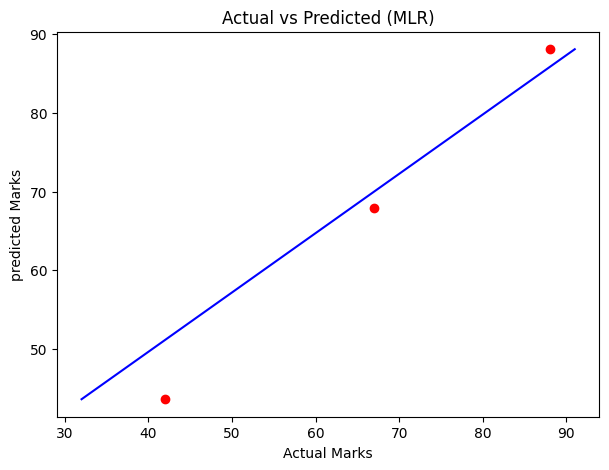

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='Red')
plt.plot([y.min(), y.max()],[y_pred.min(), y_pred.max()], color='Blue')
plt.xlabel('Actual Marks')
plt.ylabel("predicted Marks")
plt.title('Actual vs Predicted (MLR)')
plt.show()

Residual Plot

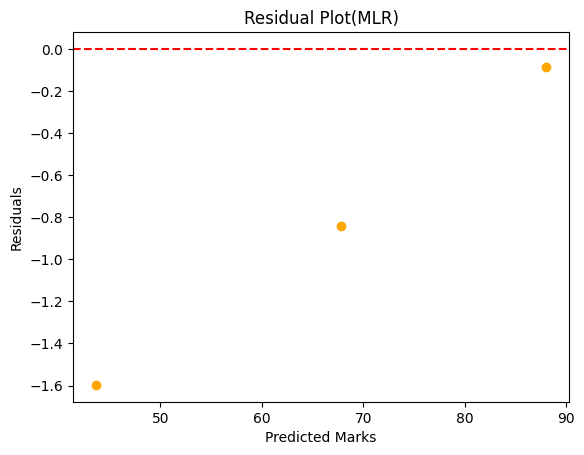

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color='Orange')
plt.axhline(y=0, color='Red', linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot(MLR)')
plt.show()